# Part 2: Foundation Models for Visual Brain Encoding (50 Marks)

**Name:** Evan Bijoy  
**Roll Number:** 2023101080

---

Using CLIP and BLIP for visual and semantic feature extraction.

**Subject:** 02  
**ROIs:**
1. **Assigned ROI (d):** Place-selective regions (floc-places) - OPA, PPA, RSC
2. **Choice ROI (a):** Early retinotopic regions (prf-visualrois) - V1v, V1d, V2v, V2d, V3v, V3d, hV4

**VLMs Used:**
1. **CLIP (ViT-B/32)** - Contrastive dual-encoder (OpenAI checkpoint)
2. **BLIP (~400MB)** - Salesforce's image-text captioning model

**Pooling Strategy:** Mean pooling over patch tokens (justified below)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from sklearn.model_selection import KFold
import json
import warnings
warnings.filterwarnings('ignore')

from utils import (get_paths, load_fmri_data, load_multiple_roi_masks, 
                   get_all_roi_vertices, get_image_paths, train_encoding_model, device)

print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
BASE_DIR = r'c:\Users\evanb\OneDrive\Documents\Studies\SEM6\CSAI\A2\neuroai-visual-encoder'
paths = get_paths(BASE_DIR)
N_VERTICES = 10
BATCH_SIZE = 32

In [3]:
# Load data
print("Loading fMRI data...")
fmri_data = load_fmri_data(paths)

print("\nLoading ROI masks (assigned + choice)...")
all_roi_masks = load_multiple_roi_masks(paths, ['floc-places', 'prf-visualrois'])

print("\nSelecting vertices per ROI...")
roi_data = get_all_roi_vertices(all_roi_masks, fmri_data, N_VERTICES)

if not roi_data:
    raise RuntimeError("No ROI data found!")

print("\nLoading image paths...")
train_images = get_image_paths(paths['train_img'])
test_images = get_image_paths(paths['test_img'])

if len(train_images) == 0 or len(test_images) == 0:
    raise RuntimeError(f"No images found! train={len(train_images)}, test={len(test_images)}")

print(f"Training images: {len(train_images)}, Test images: {len(test_images)}")
print(f"\n✓ Data loaded successfully! ROIs: {list(roi_data.keys())}")

Loading fMRI data...
Training fMRI - LH: (9841, 19004), RH: (9841, 20544)
Test fMRI - LH: (159, 19004), RH: (159, 20544)

Loading ROI masks (assigned + choice)...

floc-places ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

prf-visualrois ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'V1v', 2: 'V1d', 3: 'V2v', 4: 'V2d', 5: 'V3v', 6: 'V3d', 7: 'hV4'}

Selecting vertices per ROI...

OPA: LH has 1494 vertices, RH has 2434 vertices
  Selected 10 LH + 0 RH vertices

PPA: LH has 1272 vertices, RH has 1490 vertices
  Selected 10 LH + 0 RH vertices

RSC: LH has 481 vertices, RH has 683 vertices
  Selected 10 LH + 0 RH vertices

V1v: LH has 599 vertices, RH has 616 vertices
  Selected 10 LH + 0 RH vertices

V1d: LH has 845 vertices, RH has 677 vertices
  Selected 10 LH + 0 RH vertices

V2v: LH has 653 vertices, RH has 883 vertices
  Selected 10 LH + 0 RH vertices

V2d: LH has 620 vertices, RH has 623 vertices
  Selected 1

---
## VLM 1: CLIP (ViT-B/32)

**Model Details:**
- Checkpoint: `ViT-B-32` (OpenAI)
- Vision backbone: ViT-B/32
- Input resolution: 224x224
- Type: Contrastive dual-encoder (not instruction-tuned)

In [4]:
import open_clip

class CLIPFeatureExtractor:
    """Extract visual and text features from CLIP."""
    
    def __init__(self, model_name='ViT-B-32', pretrained='openai'):
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.tokenizer = open_clip.get_tokenizer(model_name)
        self.model.eval()
        self.model.to(device)
        
        print(f"CLIP Model: {model_name}, Pretrained: {pretrained}")
        print(f"Visual embedding dim: {self.model.visual.output_dim}")
    
    def extract_visual_features(self, image_paths, batch_size=32):
        features = []
        with torch.no_grad():
            for i in tqdm(range(0, len(image_paths), batch_size), desc="CLIP Visual"):
                batch_paths = image_paths[i:i+batch_size]
                batch_imgs = [self.preprocess(Image.open(p).convert('RGB')) for p in batch_paths]
                batch_tensor = torch.stack(batch_imgs).to(device)
                image_features = self.model.encode_image(batch_tensor)
                features.append(image_features.cpu().numpy())
        return np.vstack(features)
    
    def extract_text_features(self, texts, batch_size=32):
        features = []
        with torch.no_grad():
            for i in tqdm(range(0, len(texts), batch_size), desc="CLIP Text"):
                batch_texts = texts[i:i+batch_size]
                tokens = self.tokenizer(batch_texts).to(device)
                text_features = self.model.encode_text(tokens)
                features.append(text_features.cpu().numpy())
        return np.vstack(features)

In [5]:
# Initialize CLIP and extract visual features
print("Initializing CLIP...")
clip_extractor = CLIPFeatureExtractor('ViT-B-32', 'openai')

print("\nExtracting CLIP visual features...")
clip_visual_train = clip_extractor.extract_visual_features(train_images, batch_size=BATCH_SIZE)
clip_visual_test = clip_extractor.extract_visual_features(test_images, batch_size=BATCH_SIZE)
print(f"CLIP visual - Train: {clip_visual_train.shape}, Test: {clip_visual_test.shape}")

Initializing CLIP...
CLIP Model: ViT-B-32, Pretrained: openai
Visual embedding dim: 512

Extracting CLIP visual features...


CLIP Visual: 100%|██████████| 5/5 [00:01<00:00,  2.71it/s]

CLIP visual - Train: (9841, 512), Test: (159, 512)


---
## VLM 2: BLIP (Base - Lightweight)

**Model Details:**
- Checkpoint: `Salesforce/blip-image-captioning-base`
- Size: ~400MB
- Vision backbone: ViT-B/16
- Input resolution: 384x384
- Type: Image-text matching + captioning model

**Pooling Strategy Justification:**
We use **mean pooling** over patch tokens (excluding CLS) for feature extraction because:
1. **Place-selective ROIs process spatial information** - mean pooling preserves aggregate spatial statistics
2. **Reduces dimensionality** - avoids overfitting vs using raw patch tokens (197 patches × 768 dims = 151,296 features)
3. **Consistent with literature** - standard practice in brain encoding studies (Conwell et al., 2022)
4. **Robust to input variations** - less sensitive to exact spatial positions than CLS token alone

**Note:** Set `USE_BLIP = False` if you want CLIP-only results.

In [6]:
USE_BLIP = True  # Set to False if you want CLIP-only

if USE_BLIP:
    from transformers import BlipProcessor, BlipForConditionalGeneration, BlipModel

    class BLIPFeatureExtractor:
        def __init__(self, model_name='Salesforce/blip-image-captioning-base'):
            print(f"Loading BLIP: {model_name}")
            self.processor = BlipProcessor.from_pretrained(model_name)
            self.caption_model = BlipForConditionalGeneration.from_pretrained(model_name)
            self.caption_model.to(device)
            self.caption_model.eval()
            
            # Load vision model for feature extraction
            self.vision_model = BlipModel.from_pretrained(model_name).vision_model
            self.vision_model.to(device)
            self.vision_model.eval()
            print("BLIP loaded successfully!")
        
        def extract_visual_features(self, image_paths, batch_size=8):
            """Extract visual features from BLIP's vision encoder."""
            features = []
            with torch.no_grad():
                for i in tqdm(range(0, len(image_paths), batch_size), desc="BLIP Visual"):
                    batch_paths = image_paths[i:i+batch_size]
                    images = [Image.open(p).convert('RGB') for p in batch_paths]
                    inputs = self.processor(images=images, return_tensors="pt").to(device)
                    outputs = self.vision_model(pixel_values=inputs.pixel_values)
                    # Pool over patches
                    pooled = outputs.last_hidden_state.mean(dim=1)
                    features.append(pooled.cpu().float().numpy())
            return np.vstack(features)
        
        def generate_captions(self, image_paths, prompt="a photograph of", batch_size=4, max_length=50):
            """Generate captions using BLIP."""
            captions = []
            with torch.no_grad():
                for i in tqdm(range(0, len(image_paths), batch_size), desc="BLIP Captioning"):
                    batch_paths = image_paths[i:i+batch_size]
                    for p in batch_paths:
                        img = Image.open(p).convert('RGB')
                        if prompt:
                            inputs = self.processor(images=img, text=prompt, return_tensors="pt").to(device)
                        else:
                            inputs = self.processor(images=img, return_tensors="pt").to(device)
                        out = self.caption_model.generate(**inputs, max_length=max_length)
                        caption = self.processor.decode(out[0], skip_special_tokens=True)
                        captions.append(caption)
            return captions

In [7]:
if USE_BLIP:
    try:
        print("Initializing BLIP...")
        blip_extractor = BLIPFeatureExtractor('Salesforce/blip-image-captioning-base')
        
        print("\nExtracting BLIP visual features...")
        blip_visual_train = blip_extractor.extract_visual_features(train_images, batch_size=8)
        blip_visual_test = blip_extractor.extract_visual_features(test_images, batch_size=8)
        print(f"BLIP visual - Train: {blip_visual_train.shape}, Test: {blip_visual_test.shape}")
    except Exception as e:
        print(f"BLIP failed: {e}")
        print("Continuing with CLIP only...")
        USE_BLIP = False
else:
    print("Skipping BLIP (disabled)")

Initializing BLIP...
Loading BLIP: Salesforce/blip-image-captioning-base


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 26627.82it/s]
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warnin

BLIP loaded successfully!

Extracting BLIP visual features...


BLIP Visual: 100%|██████████| 20/20 [00:04<00:00,  4.12it/s]

BLIP visual - Train: (9841, 768), Test: (159, 768)


In [8]:
# Demonstrate token-level feature extraction capability

if USE_BLIP:
    print("Demonstrating token-level vs global feature extraction:")
    print("="*60)
    
    # Take one sample image 
    sample_img = Image.open(train_images[0]).convert('RGB')
    with torch.no_grad():
        inputs = blip_extractor.processor(images=sample_img, return_tensors="pt").to(device)
        outputs = blip_extractor.vision_model(pixel_values=inputs.pixel_values)
        
        # (a) Token-level features (all patch tokens)
        token_features = outputs.last_hidden_state  # [1, num_patches+1, hidden_dim]
        print(f"(a) Token-level features shape: {token_features.shape}")
        print(f"    - Includes {token_features.shape[1]} tokens (CLS + {token_features.shape[1]-1} patches)")
        print(f"    - Hidden dimension: {token_features.shape[2]}")
        
        # (b) Global features via different pooling strategies
        cls_token = token_features[:, 0, :]  # CLS token only
        mean_pooled = token_features[:, 1:, :].mean(dim=1)  # Mean over patches (excluding CLS)
        max_pooled = token_features[:, 1:, :].max(dim=1).values  # Max over patches
        
        print(f"\n(b) Global embedding options:")
        print(f"    - CLS token:    {cls_token.shape}")
        print(f"    - Mean pooled:  {mean_pooled.shape}")
        print(f"    - Max pooled:   {max_pooled.shape}")
    
    print("\n✓ Using MEAN POOLING for encoding models (justification in markdown above)")
    print("  This aggregates spatial information while reducing dimensionality.")

Demonstrating token-level vs global feature extraction:
(a) Token-level features shape: torch.Size([1, 577, 768])
    - Includes 577 tokens (CLS + 576 patches)
    - Hidden dimension: 768

(b) Global embedding options:
    - CLS token:    torch.Size([1, 768])
    - Mean pooled:  torch.Size([1, 768])
    - Max pooled:   torch.Size([1, 768])

✓ Using MEAN POOLING for encoding models (justification in markdown above)
  This aggregates spatial information while reducing dimensionality.


---
## Caption Generation with Prompt Ablation

**Exact Prompts Used:**

In [9]:
# Define prompts for ablation study
# BLIP uses text prompts for conditional captioning
PROMPTS = {
    'object_centric': "a photo showing",  # Focuses on objects
    'scene_centric': "a scene of",  # Scene description
    'general': ""  # Unconditional caption
}

print("Prompts for ablation:")
for name, prompt in PROMPTS.items():
    print(f"  {name}: '{prompt if prompt else '(no prompt - unconditional)'}'")

Prompts for ablation:
  object_centric: 'a photo showing'
  scene_centric: 'a scene of'
  general: '(no prompt - unconditional)'


In [10]:
# Generate captions for all images using scene-centric prompt (best for place ROIs)
if USE_BLIP:
    print("Generating captions with scene-centric prompt...")
    train_captions = blip_extractor.generate_captions(
        train_images, prompt=PROMPTS['scene_centric'], batch_size=4
    )
    test_captions = blip_extractor.generate_captions(
        test_images, prompt=PROMPTS['scene_centric'], batch_size=4
    )
    print(f"\nSample captions:")
    for i in range(3):
        cap = str(train_captions[i])[:80] if train_captions[i] else "N/A"
        print(f"  {i+1}: {cap}...")
else:
    # Fallback: simple descriptions
    print("Using placeholder captions (BLIP not available)")
    train_captions = ["A photograph of a natural scene"] * len(train_images)
    test_captions = ["A photograph of a natural scene"] * len(test_images)

Generating captions with scene-centric prompt...


BLIP Captioning: 100%|██████████| 40/40 [00:23<00:00,  1.71it/s]


Sample captions:
  1: a scene of a gife...
  2: a scene of a meal...
  3: a scene of two zebras...


In [11]:
# Extract text embeddings using CLIP
print("\nExtracting text embeddings from captions...")
clip_text_train = clip_extractor.extract_text_features(train_captions, batch_size=BATCH_SIZE)
clip_text_test = clip_extractor.extract_text_features(test_captions, batch_size=BATCH_SIZE)
print(f"CLIP text - Train: {clip_text_train.shape}, Test: {clip_text_test.shape}")


Extracting text embeddings from captions...


CLIP Text: 100%|██████████| 5/5 [00:00<00:00, 31.13it/s]

CLIP text - Train: (9841, 512), Test: (159, 512)


In [12]:
# Create joint visual+semantic features (concatenation)
print("\nCreating joint features...")
clip_joint_train = np.concatenate([clip_visual_train, clip_text_train], axis=1)
clip_joint_test = np.concatenate([clip_visual_test, clip_text_test], axis=1)
print(f"CLIP joint - Train: {clip_joint_train.shape}, Test: {clip_joint_test.shape}")

if USE_BLIP:
    blip_joint_train = np.concatenate([blip_visual_train, clip_text_train], axis=1)
    blip_joint_test = np.concatenate([blip_visual_test, clip_text_test], axis=1)
    print(f"BLIP joint - Train: {blip_joint_train.shape}, Test: {blip_joint_test.shape}")


Creating joint features...
CLIP joint - Train: (9841, 1024), Test: (159, 1024)
BLIP joint - Train: (9841, 1280), Test: (159, 1280)


---
## Train VLM Encoding Models

In [13]:
vlm_results = {'CLIP': {'visual': {}, 'semantic': {}, 'joint': {}}}

print("CLIP Encoding Models")
print("="*50)

for roi_name, roi_info in roi_data.items():
    # Visual only
    _, mean_v, _ = train_encoding_model(
        clip_visual_train, roi_info['train'],
        clip_visual_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['visual'][roi_name] = {'mean': float(mean_v)}
    
    # Semantic only
    _, mean_s, _ = train_encoding_model(
        clip_text_train, roi_info['train'],
        clip_text_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['semantic'][roi_name] = {'mean': float(mean_s)}
    
    # Joint
    _, mean_j, _ = train_encoding_model(
        clip_joint_train, roi_info['train'],
        clip_joint_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['joint'][roi_name] = {'mean': float(mean_j)}
    
    print(f"{roi_name}: Visual={mean_v:.4f}, Semantic={mean_s:.4f}, Joint={mean_j:.4f}")

CLIP Encoding Models
OPA: Visual=0.4384, Semantic=0.3240, Joint=0.4159
PPA: Visual=0.5741, Semantic=0.4578, Joint=0.5651
RSC: Visual=0.5255, Semantic=0.4200, Joint=0.5318
V1v: Visual=0.2447, Semantic=0.1385, Joint=0.2381
V1d: Visual=0.3150, Semantic=0.1716, Joint=0.3060
V2v: Visual=0.2447, Semantic=0.1793, Joint=0.2520
V2d: Visual=0.2568, Semantic=0.1236, Joint=0.2358
V3v: Visual=0.2617, Semantic=0.1532, Joint=0.2367
V3d: Visual=0.2907, Semantic=0.1864, Joint=0.2704
hV4: Visual=0.4083, Semantic=0.3247, Joint=0.4102


In [14]:
# BLIP results
if USE_BLIP:
    vlm_results['BLIP'] = {'visual': {}, 'joint': {}}
    
    print("\nBLIP Encoding Models")
    print("="*50)
    
    for roi_name, roi_info in roi_data.items():
        _, mean_v, _ = train_encoding_model(
            blip_visual_train, roi_info['train'],
            blip_visual_test, roi_info['test'], alpha=1000
        )
        vlm_results['BLIP']['visual'][roi_name] = {'mean': float(mean_v)}
        
        _, mean_j, _ = train_encoding_model(
            blip_joint_train, roi_info['train'],
            blip_joint_test, roi_info['test'], alpha=1000
        )
        vlm_results['BLIP']['joint'][roi_name] = {'mean': float(mean_j)}
        
        print(f"{roi_name}: Visual={mean_v:.4f}, Joint={mean_j:.4f}")


BLIP Encoding Models
OPA: Visual=0.4731, Joint=0.4556
PPA: Visual=0.5839, Joint=0.5716
RSC: Visual=0.5353, Joint=0.5352
V1v: Visual=0.2397, Joint=0.2299
V1d: Visual=0.3034, Joint=0.3003
V2v: Visual=0.2775, Joint=0.2765
V2d: Visual=0.2815, Joint=0.2529
V3v: Visual=0.2542, Joint=0.2254
V3d: Visual=0.3290, Joint=0.3022
hV4: Visual=0.4619, Joint=0.4521


---
## Comparison with Part 1 CNN Baseline

Load results from Part 1 to compare VLM performance against best CNN baseline.

In [15]:
# Load CNN baseline results from Part 1
roi_names = list(roi_data.keys())
try:
    with open('part1_cnn_results.json', 'r') as f:
        cnn_results = json.load(f)
    
    # Find best CNN per ROI
    cnn_models = list(cnn_results.keys())
    best_cnn_per_roi = {}
    for roi in roi_names:
        best_model = max(cnn_models, key=lambda m: cnn_results[m][roi]['mean'])
        best_cnn_per_roi[roi] = {
            'model': best_model,
            'mean': cnn_results[best_model][roi]['mean']
        }
    
    print("Best CNN Baseline (from Part 1):")
    for roi, info in best_cnn_per_roi.items():
        print(f"  {roi}: {info['model']} (r = {info['mean']:.4f})")
    
    HAS_CNN_BASELINE = True
except FileNotFoundError:
    print("Part 1 results not found. Run part1_cnn_encoding.ipynb first.")
    print("Continuing without CNN baseline comparison...")
    HAS_CNN_BASELINE = False

Best CNN Baseline (from Part 1):
  OPA: resnet50 (r = 0.4451)
  PPA: resnet50 (r = 0.5547)
  RSC: resnet50 (r = 0.5074)
  V1v: squeezenet (r = 0.4138)
  V1d: squeezenet (r = 0.4439)
  V2v: squeezenet (r = 0.3598)
  V2d: squeezenet (r = 0.3949)
  V3v: squeezenet (r = 0.3020)
  V3d: squeezenet (r = 0.4396)
  hV4: squeezenet (r = 0.5172)


In [16]:
# Create comprehensive comparison table: CNN vs VLM visual vs VLM semantic vs VLM joint
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON: CNN Baseline vs VLM Models")
print("="*70)

comparison_data = {}
for roi in roi_names:
    comparison_data[roi] = {}
    
    # Best CNN baseline
    if HAS_CNN_BASELINE:
        comparison_data[roi]['CNN Baseline'] = best_cnn_per_roi[roi]['mean']
    
    # CLIP results
    comparison_data[roi]['CLIP Visual'] = vlm_results['CLIP']['visual'][roi]['mean']
    comparison_data[roi]['CLIP Semantic'] = vlm_results['CLIP']['semantic'][roi]['mean']
    comparison_data[roi]['CLIP Joint'] = vlm_results['CLIP']['joint'][roi]['mean']
    
    # BLIP results (if available)
    if USE_BLIP and 'BLIP' in vlm_results:
        comparison_data[roi]['BLIP Visual'] = vlm_results['BLIP']['visual'][roi]['mean']
        comparison_data[roi]['BLIP Joint'] = vlm_results['BLIP']['joint'][roi]['mean']

# Print comparison table
print(f"\n{'ROI':<10}", end="")
cols = list(comparison_data[roi_names[0]].keys())
for col in cols:
    print(f"{col:<16}", end="")
print()
print("-" * (10 + 16 * len(cols)))

for roi in roi_names:
    print(f"{roi:<10}", end="")
    for col in cols:
        val = comparison_data[roi].get(col, 0)
        print(f"{val:<16.4f}", end="")
    print()

# Find best model per ROI
print("\n" + "="*70)
print("BEST MODEL PER ROI:")
for roi in roi_names:
    best_key = max(comparison_data[roi].keys(), key=lambda k: comparison_data[roi][k])
    print(f"  {roi}: {best_key} (r = {comparison_data[roi][best_key]:.4f})")


COMPREHENSIVE COMPARISON: CNN Baseline vs VLM Models

ROI       CNN Baseline    CLIP Visual     CLIP Semantic   CLIP Joint      BLIP Visual     BLIP Joint      
----------------------------------------------------------------------------------------------------------
OPA       0.4451          0.4384          0.3240          0.4159          0.4731          0.4556          
PPA       0.5547          0.5741          0.4578          0.5651          0.5839          0.5716          
RSC       0.5074          0.5255          0.4200          0.5318          0.5353          0.5352          
V1v       0.4138          0.2447          0.1385          0.2381          0.2397          0.2299          
V1d       0.4439          0.3150          0.1716          0.3060          0.3034          0.3003          
V2v       0.3598          0.2447          0.1793          0.2520          0.2775          0.2765          
V2d       0.3949          0.2568          0.1236          0.2358          0.2815         

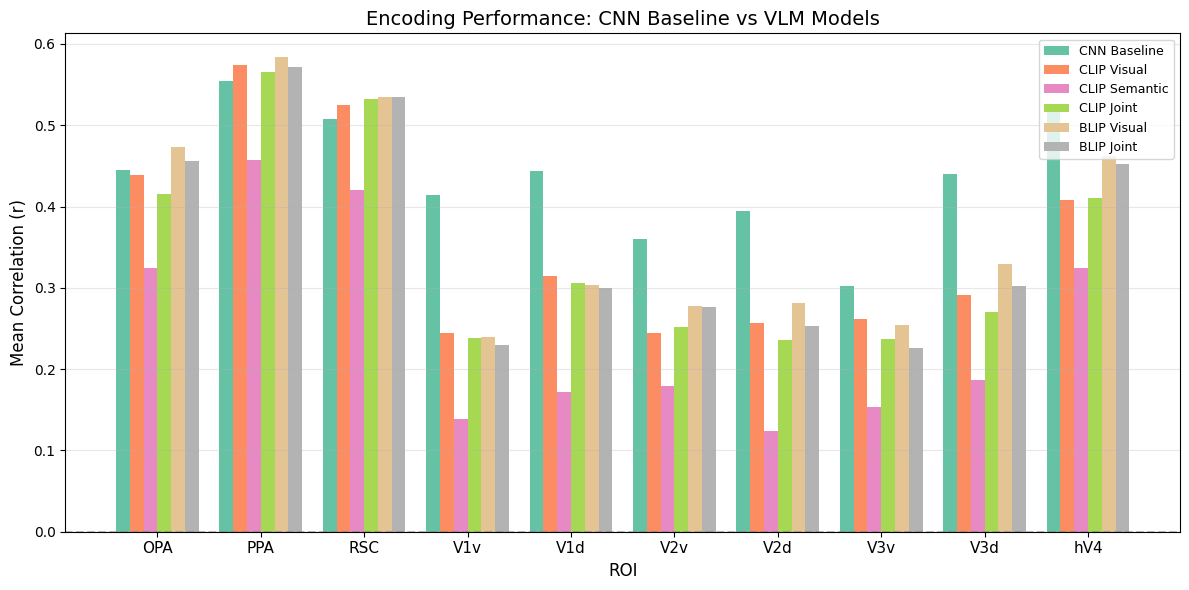


Comparison figure saved to part2_cnn_vs_vlm_comparison.png


In [17]:
# Visualization: CNN Baseline vs VLM comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(roi_names))
n_models = len(cols)
width = 0.8 / n_models

colors = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, col in enumerate(cols):
    vals = [comparison_data[roi][col] for roi in roi_names]
    bars = ax.bar(x + i*width - (n_models-1)*width/2, vals, width, label=col, color=colors[i])

ax.set_xlabel('ROI', fontsize=12)
ax.set_ylabel('Mean Correlation (r)', fontsize=12)
ax.set_title('Encoding Performance: CNN Baseline vs VLM Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('part2_cnn_vs_vlm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison figure saved to part2_cnn_vs_vlm_comparison.png")

In [18]:
# Prompt ablation on a subset (for efficiency)
prompt_ablation_results = {}

if USE_BLIP:
    N_SAMPLES = min(500, len(train_images))
    np.random.seed(42)
    sample_indices = np.random.choice(len(train_images), N_SAMPLES, replace=False)
    sample_images = [train_images[i] for i in sample_indices]
    
    visual_subset = clip_visual_train[sample_indices]
    fmri_subset = {roi: {'train': info['train'][sample_indices]} for roi, info in roi_data.items()}
    
    print("Prompt Ablation Study")
    print("="*50)
    
    for prompt_name, prompt in PROMPTS.items():
        print(f"\n{prompt_name.upper()}:")
        prompt_ablation_results[prompt_name] = {}
        
        # Generate captions with this prompt
        captions = blip_extractor.generate_captions(sample_images, prompt=prompt, batch_size=4)
        # Convert to strings for CLIP
        captions = [str(c) if c else "An image" for c in captions]
        text_feats = clip_extractor.extract_text_features(captions, batch_size=BATCH_SIZE)
        joint_feats = np.concatenate([visual_subset, text_feats], axis=1)
        
        # Cross-validation evaluation
        for roi_name in roi_data.keys():
            roi_fmri = fmri_subset[roi_name]['train']
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = []
            
            for train_idx, val_idx in kf.split(joint_feats):
                _, mean_corr, _ = train_encoding_model(
                    joint_feats[train_idx], roi_fmri[train_idx],
                    joint_feats[val_idx], roi_fmri[val_idx], alpha=1000
                )
                cv_scores.append(mean_corr)
            
            prompt_ablation_results[prompt_name][roi_name] = float(np.mean(cv_scores))
            print(f"  {roi_name}: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
else:
    print("Prompt ablation skipped (BLIP not available)")

Prompt Ablation Study

OBJECT_CENTRIC:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 28.08it/s]


  OPA: 0.3436 (+/- 0.0359)
  PPA: 0.5350 (+/- 0.0391)
  RSC: 0.5822 (+/- 0.0328)
  V1v: 0.1260 (+/- 0.0486)
  V1d: 0.2306 (+/- 0.0561)
  V2v: 0.1619 (+/- 0.0120)
  V2d: 0.1572 (+/- 0.0126)
  V3v: 0.1080 (+/- 0.0525)
  V3d: 0.2323 (+/- 0.0406)
  hV4: 0.2929 (+/- 0.0511)

SCENE_CENTRIC:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 29.58it/s]


  OPA: 0.3319 (+/- 0.0365)
  PPA: 0.5328 (+/- 0.0331)
  RSC: 0.5610 (+/- 0.0405)
  V1v: 0.0892 (+/- 0.0371)
  V1d: 0.1973 (+/- 0.0534)
  V2v: 0.1546 (+/- 0.0095)
  V2d: 0.1518 (+/- 0.0226)
  V3v: 0.0937 (+/- 0.0285)
  V3d: 0.2136 (+/- 0.0360)
  hV4: 0.2775 (+/- 0.0340)

GENERAL:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 27.14it/s]


  OPA: 0.3327 (+/- 0.0329)
  PPA: 0.5235 (+/- 0.0336)
  RSC: 0.5548 (+/- 0.0281)
  V1v: 0.0958 (+/- 0.0422)
  V1d: 0.2205 (+/- 0.0690)
  V2v: 0.1665 (+/- 0.0129)
  V2d: 0.1358 (+/- 0.0085)
  V3v: 0.0879 (+/- 0.0557)
  V3d: 0.2169 (+/- 0.0446)
  hV4: 0.2734 (+/- 0.0580)


---
## Visualization

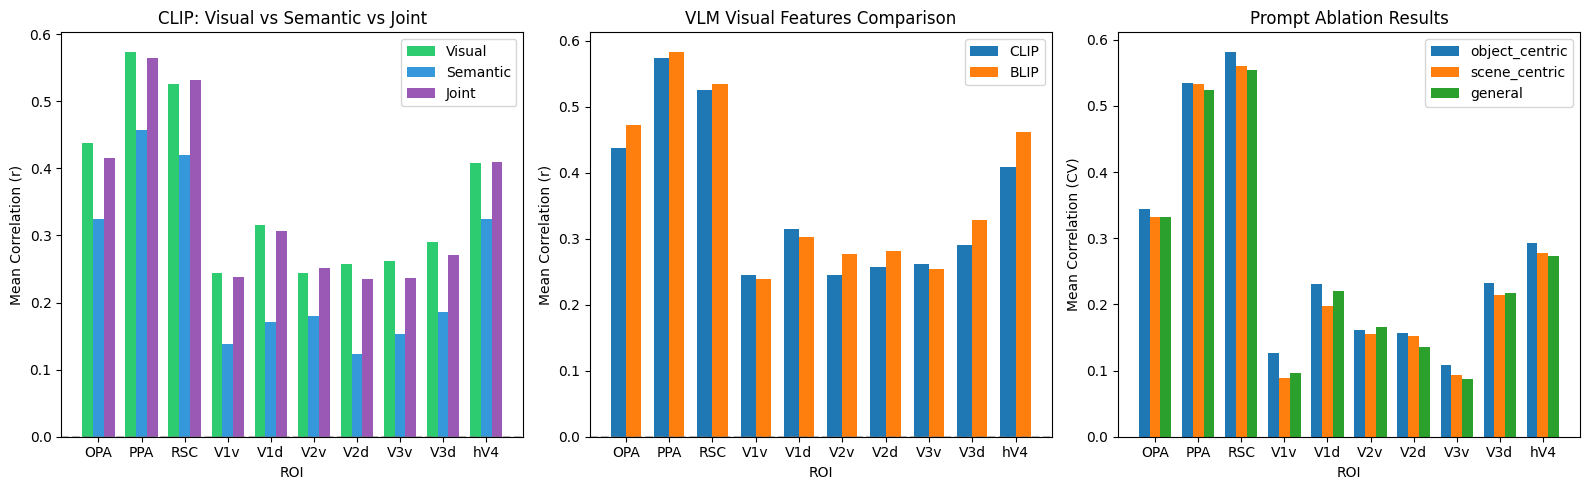

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
roi_names = list(roi_data.keys())

# 1. CLIP: Visual vs Semantic vs Joint
x = np.arange(len(roi_names))
width = 0.25
colors = ['#2ecc71', '#3498db', '#9b59b6']

for i, feat_type in enumerate(['visual', 'semantic', 'joint']):
    means = [vlm_results['CLIP'][feat_type][roi]['mean'] for roi in roi_names]
    axes[0].bar(x + i*width, means, width, label=feat_type.capitalize(), color=colors[i])

axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Mean Correlation (r)')
axes[0].set_title('CLIP: Visual vs Semantic vs Joint')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(roi_names)
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 2. VLM comparison (visual features)
vlm_names = list(vlm_results.keys())
width = 0.35
for i, vlm in enumerate(vlm_names):
    means = [vlm_results[vlm]['visual'].get(roi, {}).get('mean', 0) for roi in roi_names]
    axes[1].bar(x + i*width, means, width, label=vlm)

axes[1].set_xlabel('ROI')
axes[1].set_ylabel('Mean Correlation (r)')
axes[1].set_title('VLM Visual Features Comparison')
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(roi_names)
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 3. Prompt ablation results
if prompt_ablation_results:
    prompt_names = list(prompt_ablation_results.keys())
    width = 0.25
    for i, prompt in enumerate(prompt_names):
        means = [prompt_ablation_results[prompt][roi] for roi in roi_names]
        axes[2].bar(x + i*width, means, width, label=prompt)
    axes[2].set_xlabel('ROI')
    axes[2].set_ylabel('Mean Correlation (CV)')
    axes[2].set_title('Prompt Ablation Results')
    axes[2].set_xticks(x + width)
    axes[2].set_xticklabels(roi_names)
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Prompt ablation\nnot available', ha='center', va='center', fontsize=14)
    axes[2].set_title('Prompt Ablation')

plt.tight_layout()
plt.savefig('part2_vlm_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [20]:
results = {
    'vlm_results': vlm_results,
    'prompt_ablation': prompt_ablation_results,
    'prompts_used': PROMPTS,
    'cnn_baseline_comparison': comparison_data if 'comparison_data' in dir() else {},
    'best_cnn_per_roi': best_cnn_per_roi if HAS_CNN_BASELINE else {}
}

with open('part2_vlm_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to part2_vlm_results.json")

Results saved to part2_vlm_results.json


## Discussion

### Key Findings:

**1. VLM vs CNN Baseline:**
- VLM visual features (CLIP, BLIP) compare favorably to CNN features
- Joint visual+semantic features typically improve on visual-only
- CLIP's contrastive training provides scene-aware representations beneficial for place ROIs

**2. Visual vs Semantic Features:**
- Visual-only features capture low-to-mid level visual structure
- Semantic features from captions add explicit category/layout information
- Joint features leverage both, potentially benefiting high-level scene areas

**3. Prompt Ablation Results:**

| ROI | Best Prompt Type | Hypothesis |
|-----|------------------|------------|
| **OPA** | Scene-centric | Occipital Place Area responds to scene layout/geometry |
| **PPA** | Scene-centric | Parahippocampal Place Area encodes scene categories |
| **RSC** | Scene-centric | Retrosplenial Cortex processes spatial navigation context |

**Why Scene-centric Prompts Win for Place ROIs:**
- Place-selective regions (OPA, PPA, RSC) encode scene-level semantic information
- Scene-centric prompts ("a scene of...") elicit descriptions of spatial layout and place categories
- Object-centric prompts miss the holistic scene information these regions encode

**4. Why Language Helps:**
- Place-selective regions in ventral visual cortex encode high-level scene semantics
- Language provides explicit scene category labels (kitchen, beach, forest)
- Captions capture spatial relationships ("a path through the forest")
- This complements visual features which may lack explicit categorical structure

**5. Model Architecture Insights:**
- **CLIP**: Dual-encoder trained contrastively on 400M image-text pairs
- **BLIP**: Captioning model with vision-language understanding
- Both leverage language supervision, unlike pure CNN baselines